# TP1 - Parte 1: Análisis Exploratorio de Datos
## Mantenimiento Predictivo Industrial (Dataset i40)

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Conf general de graficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PALETTE = {'normal': '#4C72B0', 'failure': '#DD8452'}

---
## 1. Carga y vista general del dataset

In [143]:
df = pd.read_csv('i40 (datos).csv')

#renombramos las columnas para mayor comodidad
df.columns = ['idx', 'parent_device_id', 'product_type',
              'air_temp', 'process_temp', 'speed', 'torque', 'tool_wear', 'target']

print('Forma del dataset:', df.shape)
print()
print(df.drop(columns=['idx','parent_device_id']).describe())
print()
df.head(10)

Forma del dataset: (14521, 9)

           air_temp  process_temp         speed        torque     tool_wear
count  14481.000000  14521.000000  14521.000000  14521.000000  14521.000000
mean     300.478975    310.165287   1513.389436     44.955809    124.921700
std        1.952737      1.329586    313.604170     14.226641     70.105992
min      295.300000    305.700000     -1.000000      3.800000      0.000000
25%      298.900000    309.200000   1354.000000     35.990000     64.000000
50%      300.600000    310.320000   1423.000000     46.700000    127.000000
75%      302.200000    311.090000   1561.000000     55.000000    193.000000
max      304.500000    313.800000   2886.000000     76.600000    253.000000



,idx,parent_device_id,product_type,air_temp,process_temp,speed,torque,tool_wear,target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal
5,5,9840,H,298.30,309.20,1486,42.40,16,normal
6,6,18430,L,300.78,309.97,1450,61.01,143,failure
7,7,11482,L,303.14,311.31,1350,53.50,7,failure
8,8,15095,H,297.54,307.82,1610,35.68,220,failure
9,9,4085,H,302.00,310.50,1841,23.60,119,normal


In [144]:
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print()
print('=== Valores duplicados ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')

=== Tipos de datos ===
idx                   int64
parent_device_id      int64
product_type         object
air_temp            float64
process_temp        float64
speed                 int64
torque              float64
tool_wear             int64
target               object
dtype: object

=== Valores nulos por columna ===
idx                  0
parent_device_id     0
product_type         0
air_temp            40
process_temp         0
speed                0
torque               0
tool_wear            0
target               0
dtype: int64

=== Valores duplicados ===
Filas duplicadas: 0


---
## 2. Variables categóricas: proporciones

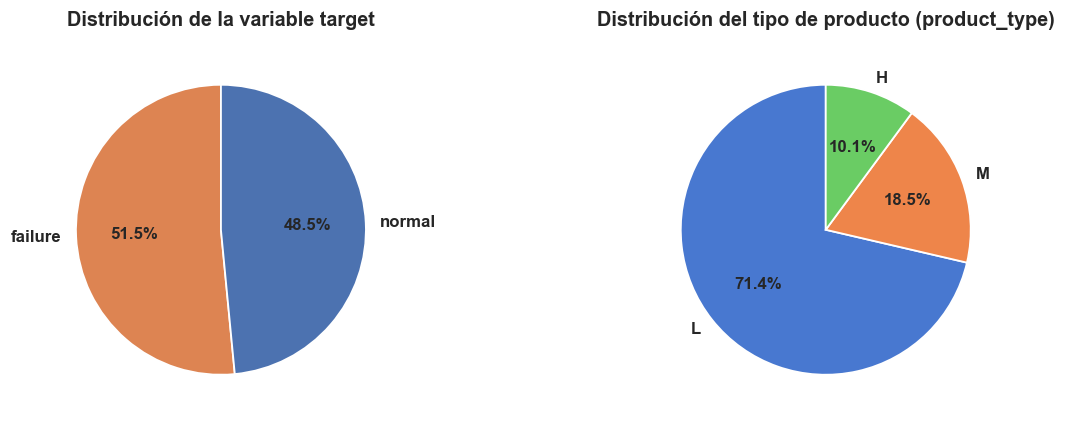

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ─────────────────────────────────────────────────────────
# Distribución de la variable target (product_type)
# ─────────────────────────────────────────────────────────
target_counts = df['target'].value_counts()

# Graficamos la torta en el primer eje (axes[0])
axes[0].pie(
    target_counts.values, 
    labels=target_counts.index, 
    autopct='%1.1f%%',         
    startangle=90,             
    colors=[PALETTE[k] for k in target_counts.index], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}, 
    textprops={'fontsize': 11, 'fontweight': 'bold'}     
)
axes[0].set_title('Distribución de la variable target', fontweight='bold', pad=15)

# ─────────────────────────────────────────────────────────
# Distribución del tipo de producto (product_type)
# ─────────────────────────────────────────────────────────
pt_counts = df['product_type'].value_counts()
pt_pct = df['product_type'].value_counts(normalize=True) * 100

axes[1].pie(
    pt_counts.values, 
    labels=pt_counts.index, 
    autopct='%1.1f%%',          
    startangle=90,              
    colors=sns.color_palette('muted', len(pt_counts)), # Usa la paleta global configurada
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}, 
    textprops={'fontsize': 11, 'fontweight': 'bold'}     
)
axes[1].set_title('Distribución del tipo de producto (product_type)', fontweight='bold', pad=15)

# Ajustes de diseño y guardado de la imagen
plt.tight_layout()
plt.savefig('fig_01_proporciones_cat.png', bbox_inches='tight')
plt.show()

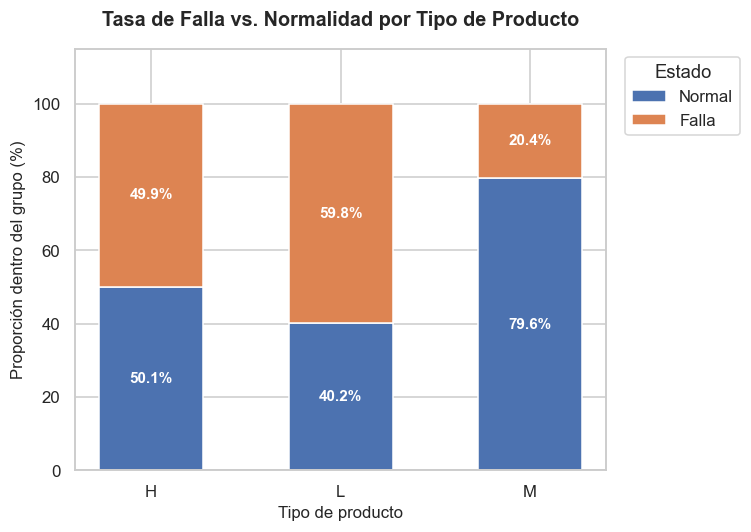

In [146]:
# ── Tasa de falla por tipo de producto (Barras Apiladas al 100%) ──
cross_tab = pd.crosstab(df['product_type'], df['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(7, 5))

# Extraemos las categorías y los porcentajes internos
productos = cross_tab.index
porcentaje_normal = cross_tab['normal'].values
porcentaje_failure = cross_tab['failure'].values

# Graficamos la base (normal)
rects1 = ax.bar(productos, porcentaje_normal, label='Normal', 
                color=PALETTE['normal'], edgecolor='white', linewidth=1, width=0.55)

# Graficamos la parte superior (failure) indicando que arranca donde termina 'normal'
rects2 = ax.bar(productos, porcentaje_failure, bottom=porcentaje_normal, label='Falla', 
                color=PALETTE['failure'], edgecolor='white', linewidth=1, width=0.55)

# Configuraciones estéticas del gráfico
ax.set_title('Tasa de Falla vs. Normalidad por Tipo de Producto', fontweight='bold', pad=15)
ax.set_xlabel('Tipo de producto')
ax.set_ylabel('Proporción dentro del grupo (%)')
ax.set_ylim(0, 115) # Espacio arriba para que no se superponga la leyenda
ax.legend(title='Estado', loc='upper left', bbox_to_anchor=(1.02, 1))

for r1, r2 in zip(rects1, rects2):
    h1 = r1.get_height() # % de normales
    h2 = r2.get_height() # % de fallas
    x = r1.get_x() + r1.get_width() / 2
    
    # Texto para 'normal'
    if h1 > 5:
        ax.text(x, h1 / 2, f'{h1:.1f}%', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10)
    # Texto para 'failure'
    if h2 > 5:
        ax.text(x, h1 + (h2 / 2), f'{h2:.1f}%', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig_02_falla_por_tipo.png', bbox_inches='tight')
plt.show()

---
## 3. Medidas estadísticas de las variables numéricas

In [147]:
num_cols = ['air_temp', 'process_temp', 'speed', 'torque', 'tool_wear']

#Funcion manual para calcular IQR y CV
def resumen_extendido(df, cols):
    rows = []
    for c in cols:
        s = df[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            'Variable': c,
            'Media': s.mean(),
            'Mediana': s.median(),
            'Moda': s.mode()[0],
            'Desv. Estándar': s.std(),
            'Varianza': s.var(),
            'Mín': s.min(),
            'Máx': s.max(),
            'Rango': s.max() - s.min(),
            'Q1': q1,
            'Q3': q3,
            'IQR': q3 - q1,
            'CV (%)': (s.std() / s.mean()) * 100 if s.mean() != 0 else np.nan,
            'Asimetría': s.skew(),
            'Curtosis': s.kurt()
        })
    return pd.DataFrame(rows).set_index('Variable')

resumen = resumen_extendido(df, num_cols)

# Medidas de tendencia central
print('=== MEDIDAS DE TENDENCIA CENTRAL ===')
print(resumen[['Media', 'Mediana', 'Moda']].round(3).to_string())
print()
# Medidas de dispersión
print('=== MEDIDAS DE DISPERSIÓN ===')
print(resumen[['Desv. Estándar', 'Varianza', 'Rango', 'IQR', 'CV (%)']].round(3).to_string())
print()
# Forma de la distribución
print('=== FORMA DE LAS DISTRIBUCIONES ===')
print(resumen[['Mín', 'Q1', 'Mediana', 'Q3', 'Máx', 'Asimetría', 'Curtosis']].round(3).to_string())

=== MEDIDAS DE TENDENCIA CENTRAL ===
                 Media  Mediana    Moda
Variable                               
air_temp       300.479   300.60   300.7
process_temp   310.165   310.32   310.6
speed         1513.389  1423.00  1377.0
torque          44.956    46.70    35.8
tool_wear      124.922   127.00   208.0

=== MEDIDAS DE DISPERSIÓN ===
              Desv. Estándar   Varianza   Rango     IQR  CV (%)
Variable                                                       
air_temp               1.953      3.813     9.2    3.30   0.650
process_temp           1.330      1.768     8.1    1.89   0.429
speed                313.604  98347.575  2887.0  207.00  20.722
torque                14.227    202.397    72.8   19.01  31.646
tool_wear             70.106   4914.850   253.0  129.00  56.120

=== FORMA DE LAS DISTRIBUCIONES ===
                Mín       Q1  Mediana       Q3     Máx  Asimetría  Curtosis
Variable                                                                   
air_temp      2

---
## 4. Distribuciones de variables numéricas

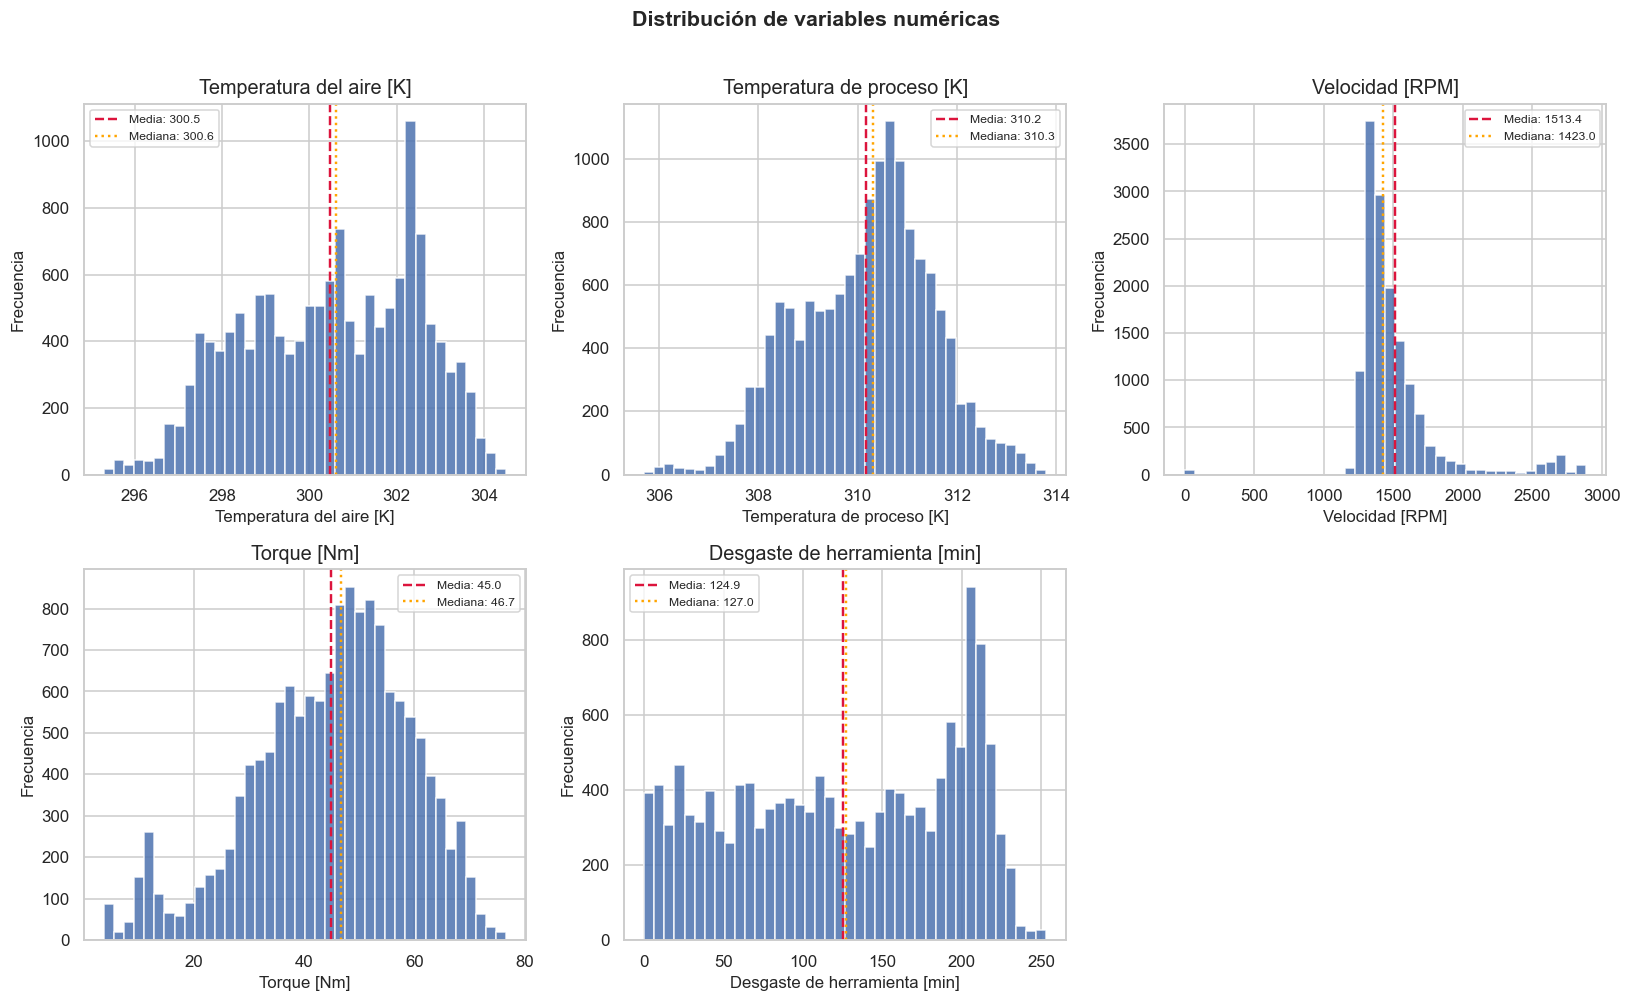

In [148]:
labels = {
    'air_temp': 'Temperatura del aire [K]',
    'process_temp': 'Temperatura de proceso [K]',
    'speed': 'Velocidad [RPM]',
    'torque': 'Torque [Nm]',
    'tool_wear': 'Desgaste de herramienta [min]'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='crimson', linewidth=1.6, linestyle='--', label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linewidth=1.6, linestyle=':', label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(labels[col])
    ax.set_xlabel(labels[col])
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Ocultar subplot vacío
axes[-1].set_visible(False)

fig.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_histogramas.png', bbox_inches='tight')
plt.show()

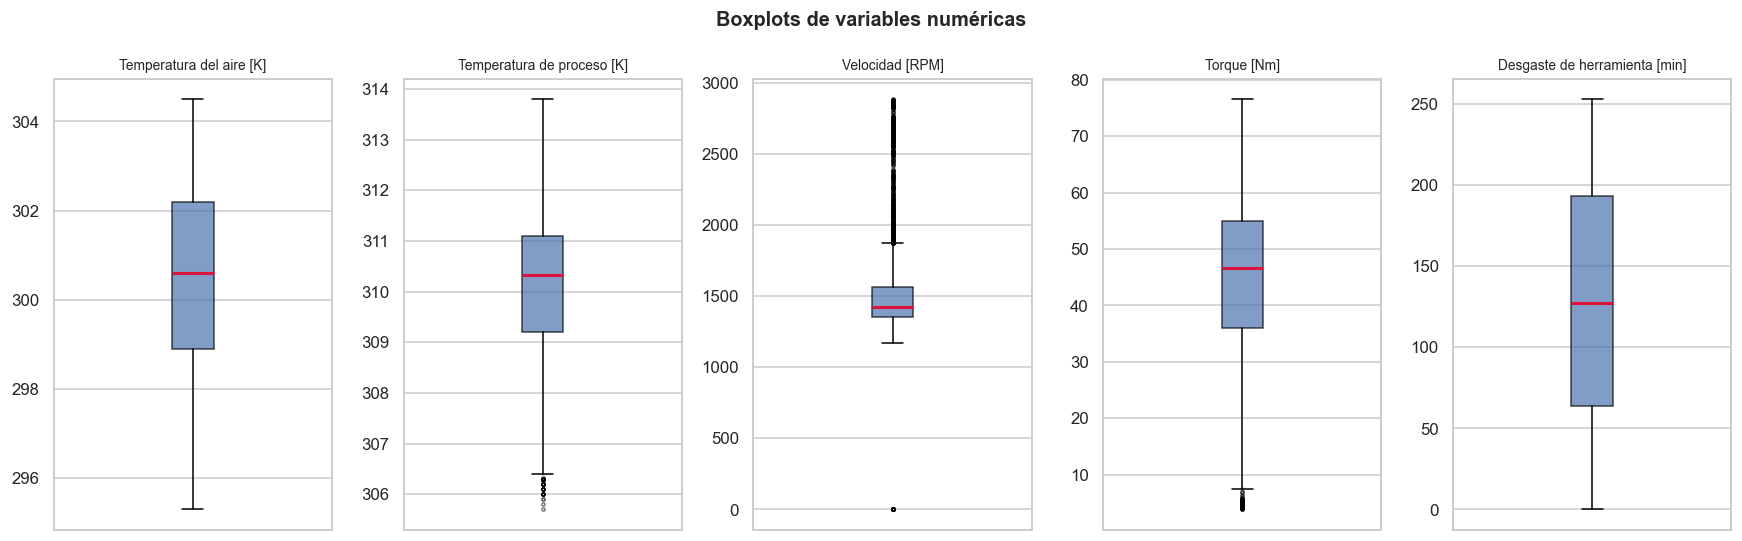

In [149]:
#Boxplots globales
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7),
               medianprops=dict(color='crimson', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(labels[col], fontsize=9)
    ax.set_xticks([])

fig.suptitle('Boxplots de variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_boxplots_global.png', bbox_inches='tight')
plt.show()

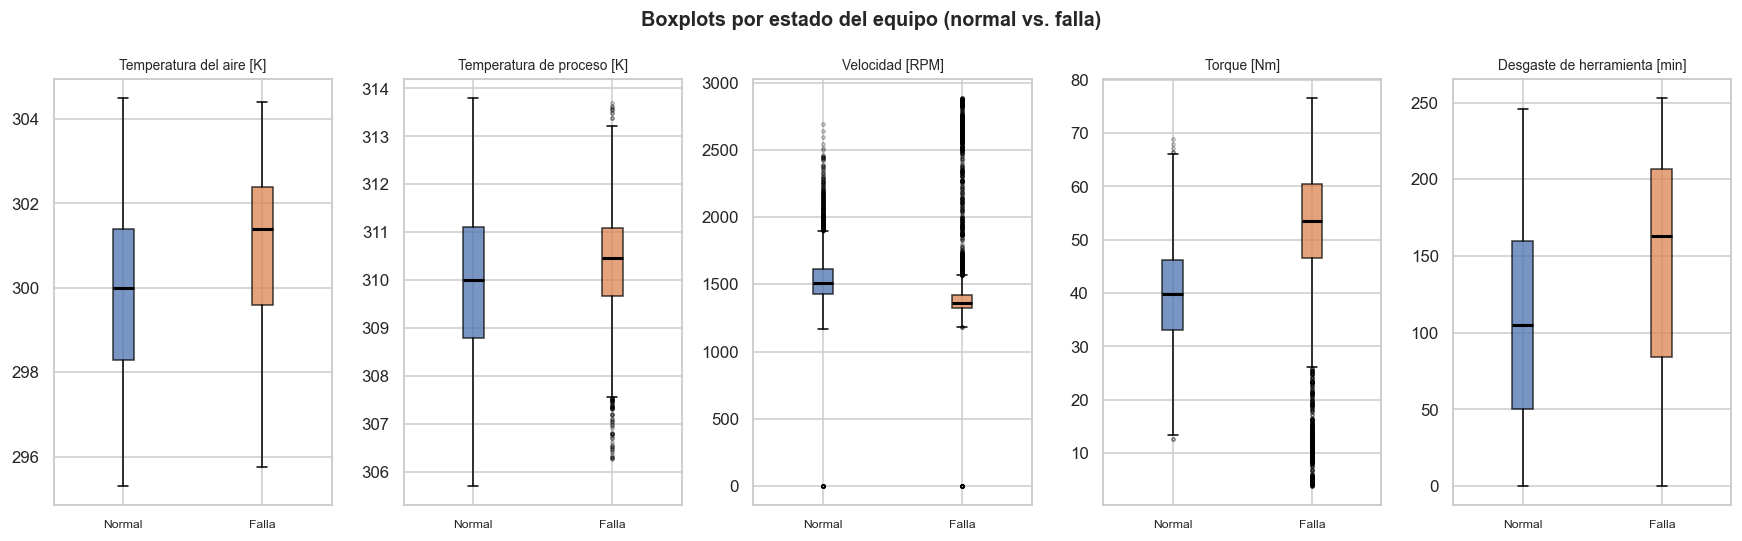

In [150]:
#Boxplots por target (normal vs failure)
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    data_groups = [df.loc[df['target'] == g, col].dropna() for g in ['normal', 'failure']]
    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    colors_bp = [PALETTE['normal'], PALETTE['failure']]
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(labels[col], fontsize=9)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Normal', 'Falla'], fontsize=8)

fig.suptitle('Boxplots por estado del equipo (normal vs. falla)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_boxplots_target.png', bbox_inches='tight')
plt.show()

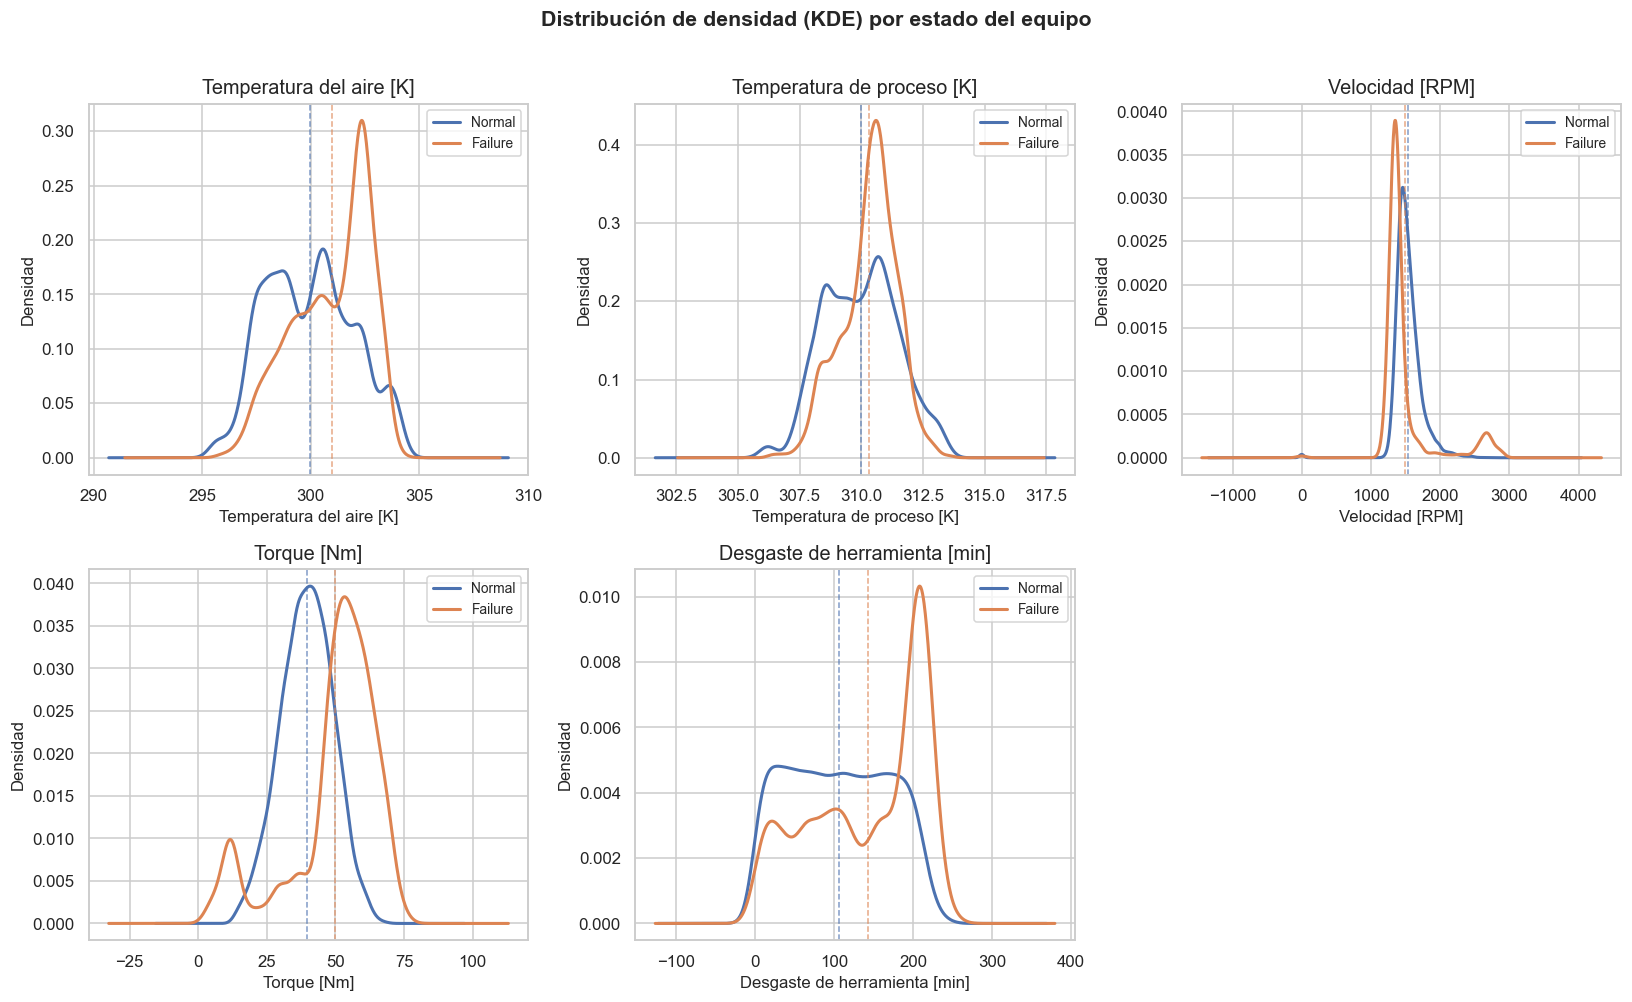

In [151]:
# KDE superpuesto por target
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for state, color in PALETTE.items():
        subset = df.loc[df['target'] == state, col]
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=state.capitalize())
        ax.axvline(subset.mean(), color=color, linewidth=1, linestyle='--', alpha=0.7)
    ax.set_title(labels[col])
    ax.set_xlabel(labels[col])
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Distribución de densidad (KDE) por estado del equipo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_kde_target.png', bbox_inches='tight')
plt.show()

---
## 5. Relaciones entre variables

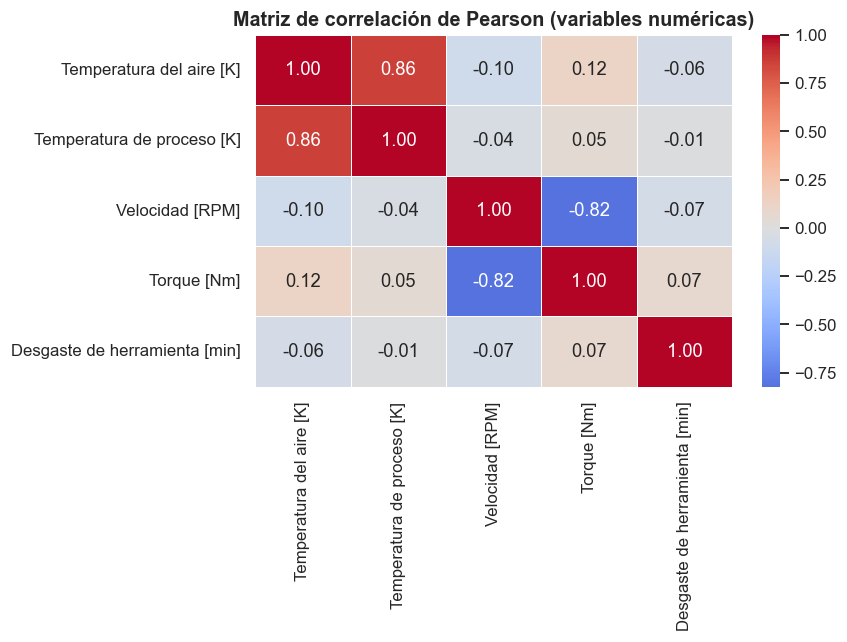


Correlaciones con mayor valor absoluto (|r| > 0.3):
        Var1     Var2         r
process_temp air_temp  0.859222
      torque    speed -0.823086


In [152]:
#Matriz de correlación
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
# Mantenemos la máscara creada solo para usarla en el filtro del print final
mask = np.triu(np.ones_like(corr, dtype=bool)) 

# Eliminamos mask=mask de los parámetros de sns.heatmap para que dibuje la matriz completa
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5,
            xticklabels=[labels[c] for c in num_cols],
            yticklabels=[labels[c] for c in num_cols])

ax.set_title('Matriz de correlación de Pearson (variables numéricas)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_correlacion.png', bbox_inches='tight')
plt.show()

print('\nCorrelaciones con mayor valor absoluto (|r| > 0.3):')
corr_pairs = (corr.where(mask == False)
                  .stack()
                  .reset_index()
                  .rename(columns={0: 'r', 'level_0': 'Var1', 'level_1': 'Var2'}))
corr_pairs = corr_pairs[corr_pairs['r'].abs() > 0.3].sort_values('r', key=abs, ascending=False)
print(corr_pairs.to_string(index=False))

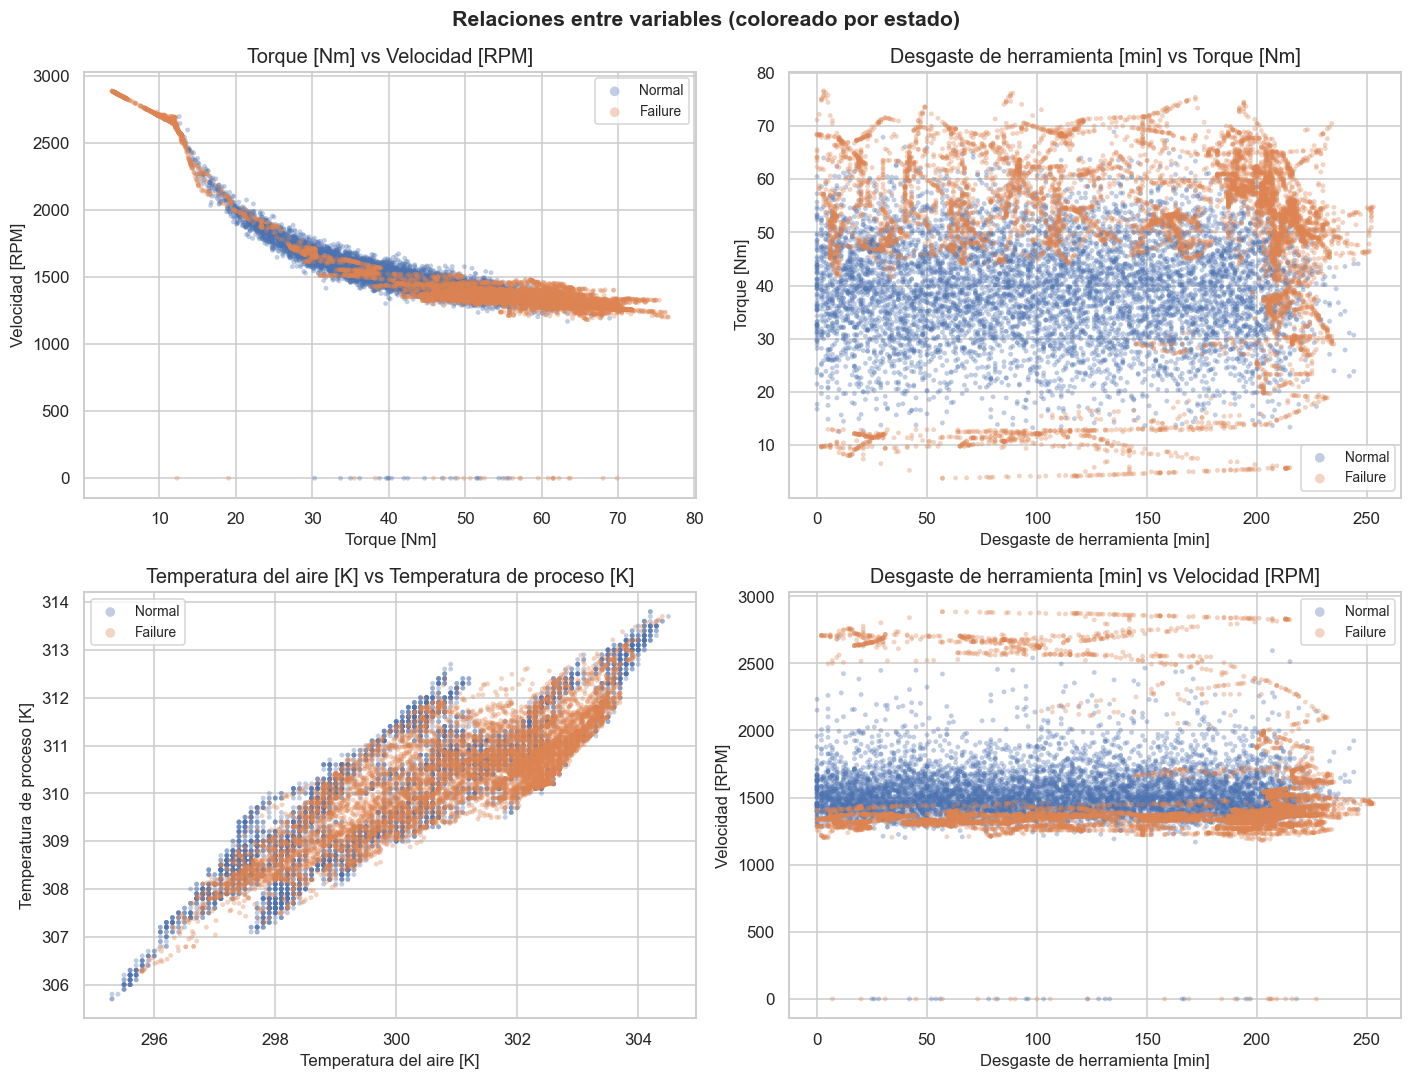

In [153]:
# Scatter plots de pares clave (coloreados por target)
pairs = [('torque', 'speed'), ('tool_wear', 'torque'),
         ('air_temp', 'process_temp'), ('tool_wear', 'speed')]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    for state, color in PALETTE.items():
        subset = df[df['target'] == state]
        ax.scatter(subset[x], subset[y], c=color, alpha=0.35,
                   s=10, label=state.capitalize(), edgecolors='none')
    ax.set_xlabel(labels[x])
    ax.set_ylabel(labels[y])
    ax.set_title(f'{labels[x]} vs {labels[y]}')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('Relaciones entre variables (coloreado por estado)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_scatter_pares.png', bbox_inches='tight')
plt.show()

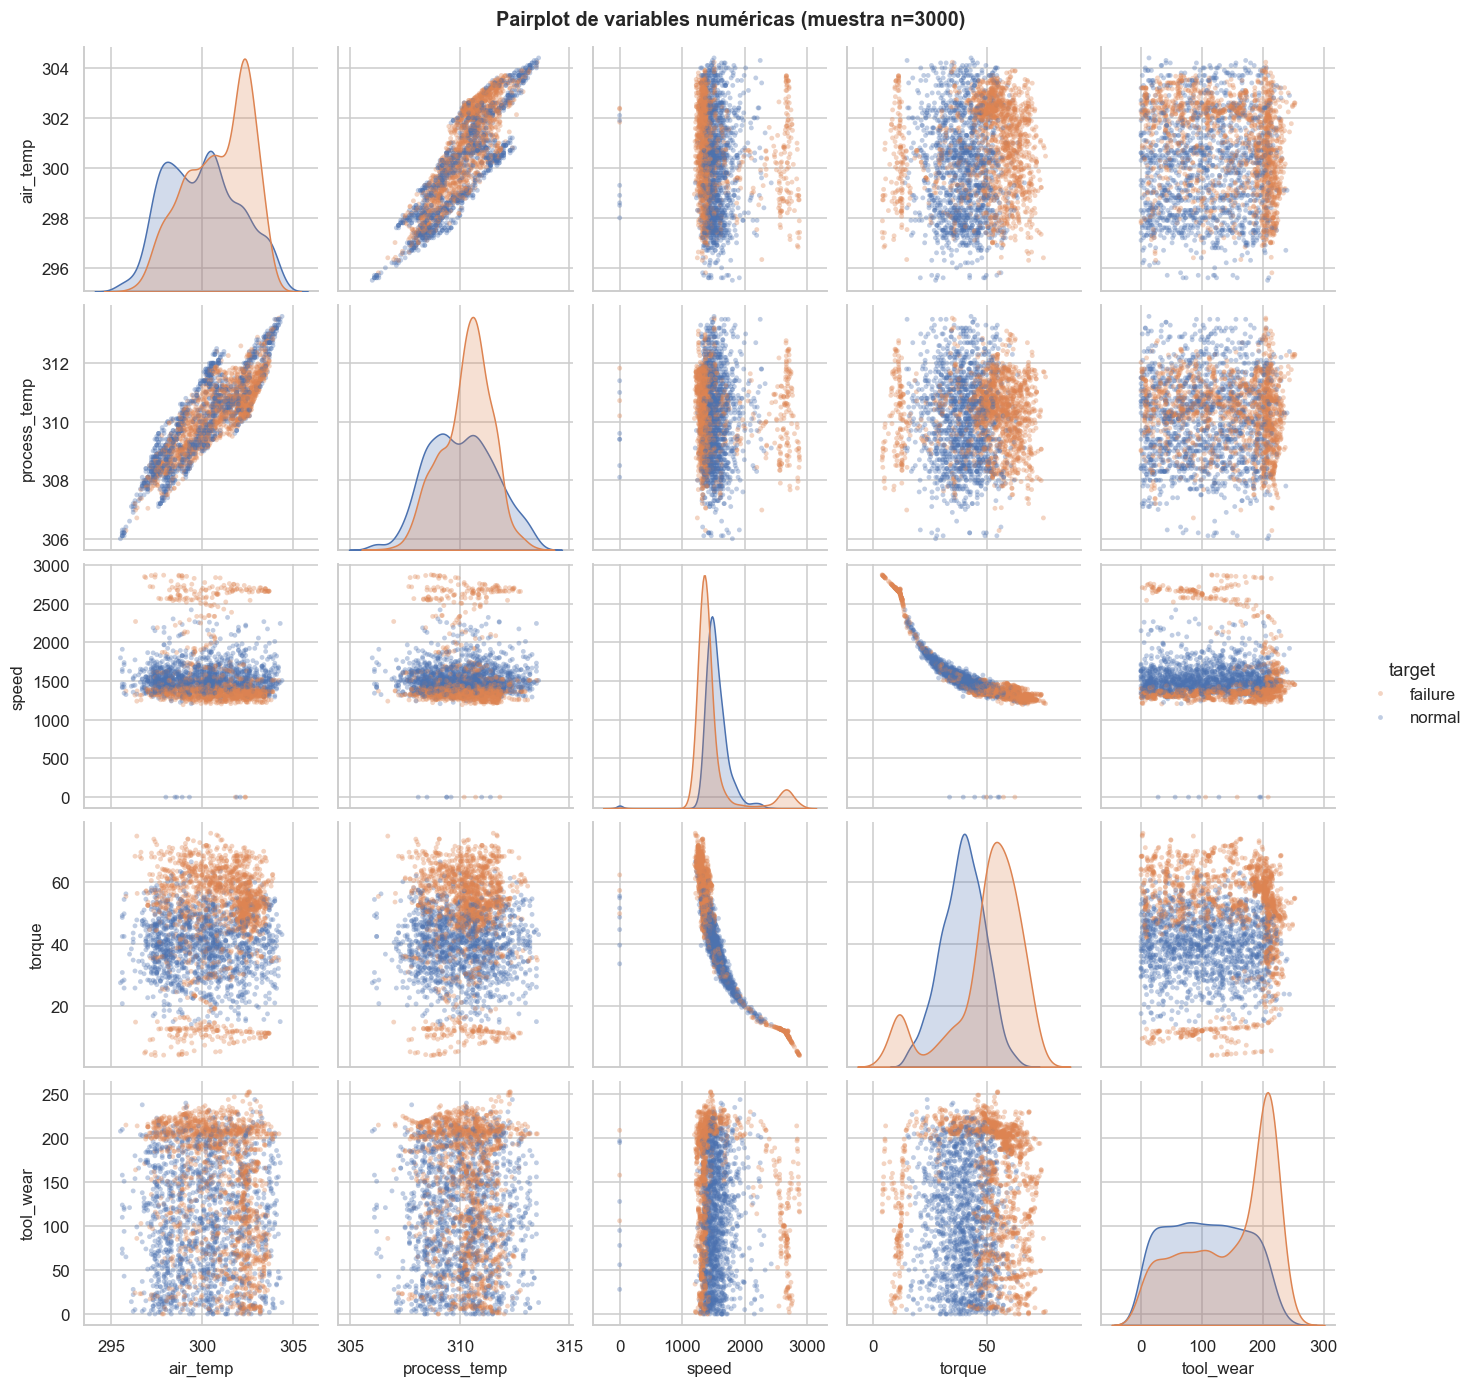

In [154]:
#Pairplot completo
sample = df.sample(n=min(3000, len(df)), random_state=42)  # muestra para velocidad
pair_df = sample[num_cols + ['target']]

pg = sns.pairplot(pair_df, hue='target', palette=PALETTE,
                  plot_kws=dict(alpha=0.35, s=10, edgecolor='none'),
                  diag_kind='kde')
pg.figure.suptitle('Pairplot de variables numéricas (muestra n=3000)', y=1.01,
                   fontsize=13, fontweight='bold')
pg.figure.savefig('fig_09_pairplot.png', bbox_inches='tight')
plt.show()

---
## 6. Análisis por tipo de producto y estado

In [155]:
# Estadísticas agrupadas por product_type y target
grouped = df.groupby(['product_type', 'target'])[num_cols].mean().round(2)
print('Media de variables numéricas por tipo de producto y estado:')
print(grouped.to_string())

Media de variables numéricas por tipo de producto y estado:
                      air_temp  process_temp    speed  torque  tool_wear
product_type target                                                     
H            failure    301.01        310.31  1440.29   50.90     140.70
             normal     299.84        309.92  1537.53   39.69     106.23
L            failure    300.91        310.31  1475.65   50.73     145.70
             normal     299.99        310.01  1537.53   39.52     105.82
M            failure    301.56        310.62  1734.74   40.59     113.17
             normal     299.96        309.98  1535.73   39.71     105.92


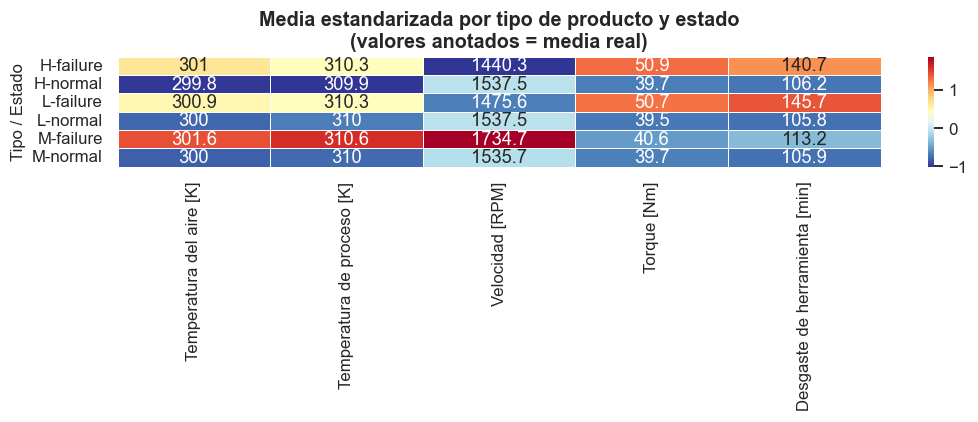

In [156]:
# Heatmap de medias por grupo
pivot = df.groupby(['product_type', 'target'])[num_cols].mean()
pivot_z = (pivot - pivot.mean()) / pivot.std()  # estandarizado para comparar escalas

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_z, annot=pivot.round(1), fmt='g', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax,
            xticklabels=[labels[c] for c in num_cols])
ax.set_title('Media estandarizada por tipo de producto y estado\n(valores anotados = media real)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Tipo / Estado')
plt.tight_layout()
plt.savefig('fig_10_heatmap_grupos.png', bbox_inches='tight')
plt.show()

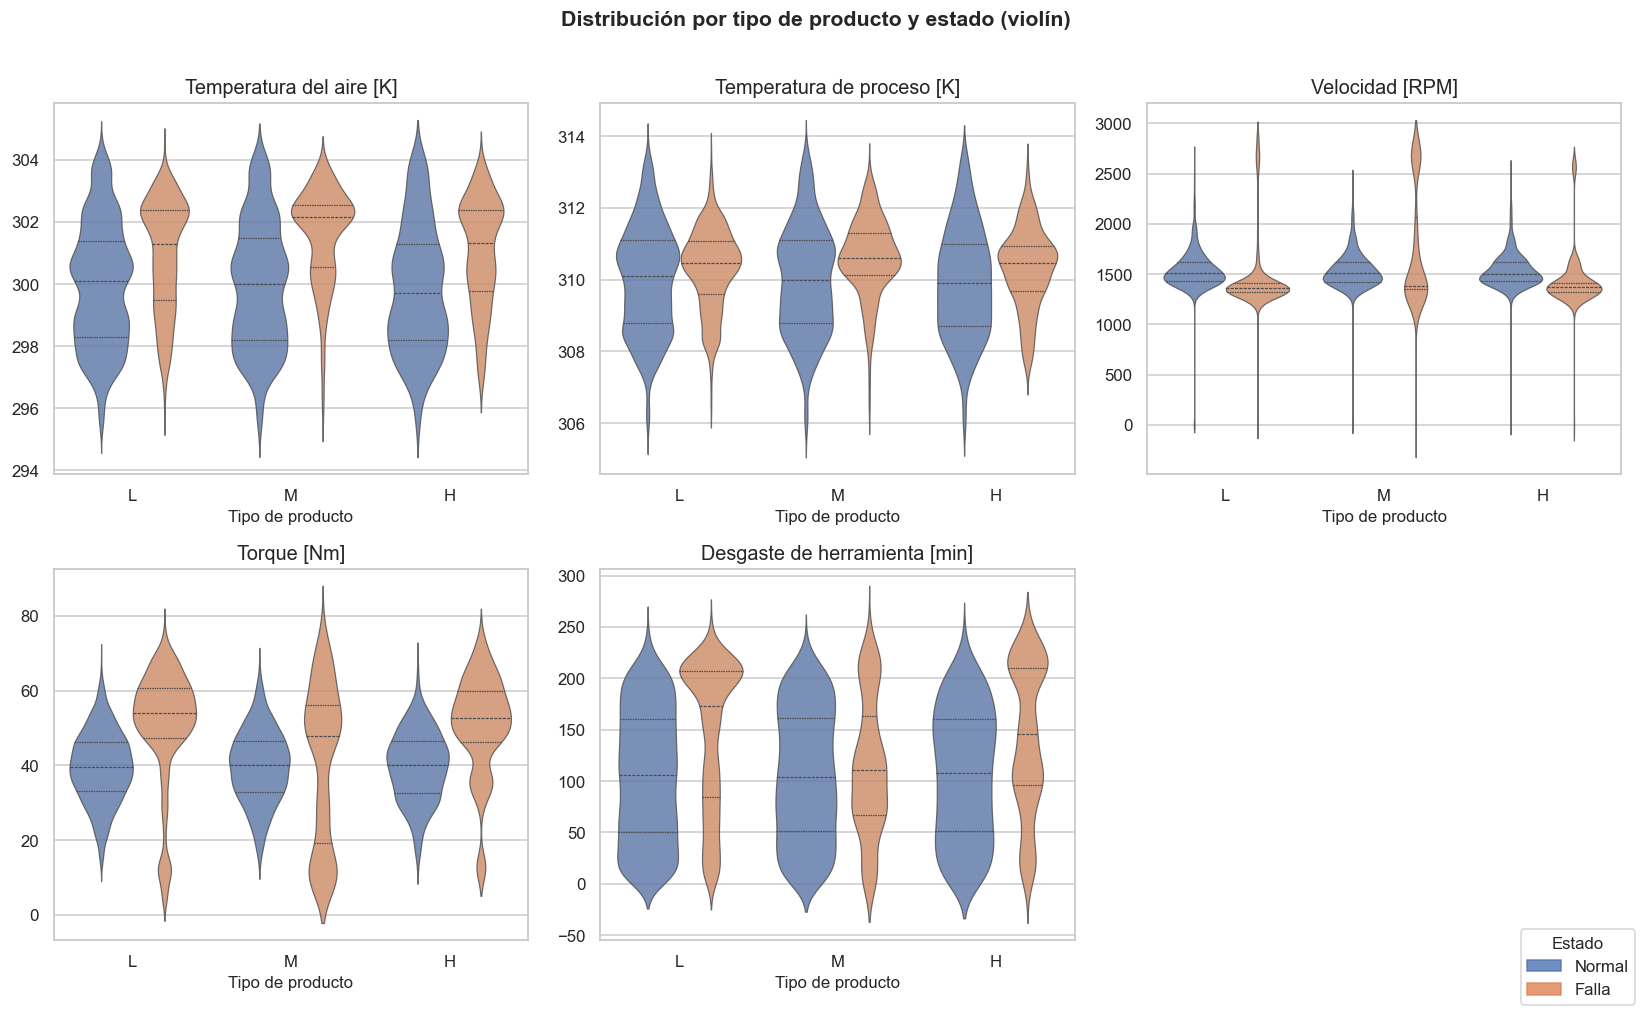

In [157]:
# Distribución de variables por tipo de producto (violín)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.violinplot(data=df, x='product_type', y=col, hue='target',
                   palette=PALETTE, split=False, inner='quartile',
                   linewidth=0.8, ax=ax, alpha=0.8)
    ax.set_title(labels[col])
    ax.set_xlabel('Tipo de producto')
    ax.set_ylabel('')
    ax.get_legend().remove()

#Leyenda global
axes[-1].set_visible(False)
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.8) for c in PALETTE.values()]
fig.legend(handles, ['Normal', 'Falla'], loc='lower right', fontsize=11,
           title='Estado', title_fontsize=11)

fig.suptitle('Distribución por tipo de producto y estado (violín)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_11_violin_tipo_target.png', bbox_inches='tight')
plt.show()

---
## 7. Detección de outliers

In [158]:
def contar_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print('=== OUTLIERS POR CRITERIO IQR ===')
print(f'{"Variable":<25} {"N outliers":>12} {"% del total":>12} {"Límite inf":>12} {"Límite sup":>12}')
print('-' * 75)
for col in num_cols:
    n_out, low, up = contar_outliers_iqr(df[col])
    pct = n_out / len(df) * 100
    print(f'{labels[col]:<25} {n_out:>12} {pct:>11.2f}% {low:>12.2f} {up:>12.2f}')

=== OUTLIERS POR CRITERIO IQR ===
Variable                    N outliers  % del total   Límite inf   Límite sup
---------------------------------------------------------------------------
Temperatura del aire [K]             0        0.00%       293.95       307.15
Temperatura de proceso [K]           67        0.46%       306.37       313.92
Velocidad [RPM]                   1186        8.17%      1043.50      1871.50
Torque [Nm]                        107        0.74%         7.48        83.52
Desgaste de herramienta [min]            0        0.00%      -129.50       386.50


---
## 8. Análisis de la variable `tool_wear` y falla acumulada

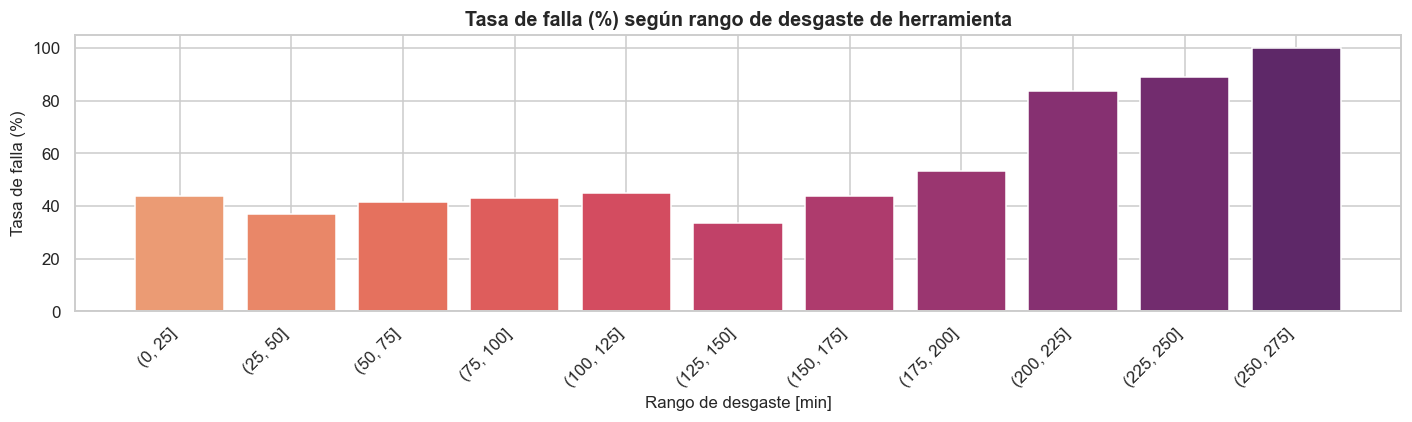

In [159]:
# ¿A qué nivel de desgaste ocurren más fallas?
bins = list(range(0, int(df['tool_wear'].max()) + 25, 25))
df['wear_bin'] = pd.cut(df['tool_wear'], bins=bins)

wear_stats = df.groupby('wear_bin', observed=True)['target'].apply(
    lambda x: (x == 'failure').mean() * 100
).reset_index()
wear_stats.columns = ['Rango desgaste', 'Tasa falla (%)']

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(wear_stats['Rango desgaste'].astype(str), wear_stats['Tasa falla (%)'],
       color=sns.color_palette('flare', len(wear_stats)), edgecolor='white')
ax.set_title('Tasa de falla (%) según rango de desgaste de herramienta', fontweight='bold')
ax.set_xlabel('Rango de desgaste [min]')
ax.set_ylabel('Tasa de falla (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_12_falla_por_desgaste.png', bbox_inches='tight')
plt.show()

df.drop(columns='wear_bin', inplace=True)

---
## 9. Resumen ejecutivo de hallazgos

In [160]:
falla_pct = (df['target'] == 'failure').mean() * 100
corr_torque_speed = df['torque'].corr(df['speed'])
corr_temps = df['air_temp'].corr(df['process_temp'])
nulos_air = df['air_temp'].isnull().sum()
speed_min = df['speed'].min()

failure_by_type = (df.groupby('product_type')['target']
                   .apply(lambda x: (x == 'failure').mean() * 100)
                   .round(1))

print('=' * 65)
print('RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO')
print('=' * 65)
print(f'\n• Dataset: {df.shape[0]:,} registros, {df.shape[1]} columnas')

print(f'\n• CALIDAD DE DATOS:')
print(f'  - air_temp: {nulos_air} valores nulos ({nulos_air/len(df)*100:.2f}% del total).')
print(f'    Se imputarán en la Parte 2.')
print(f'  - speed mínimo = {speed_min} RPM: valor físicamente imposible (erróneo).')
print(f'    Se tratará como valor atípico/erróneo en la Parte 2.')
print(f'  - Sin filas duplicadas.')

print(f'\n• BALANCE DE CLASES:')
print(f'  - Normal: {100-falla_pct:.1f}%  |  Falla: {falla_pct:.1f}%')
print(f'  - El dataset está prácticamente balanceado (~50/50).')

print(f'\n• TIPO DE PRODUCTO:')
print(f'  - Predomina el tipo L (71.4%), seguido por M (18.5%) y H (10.1%).')
print(f'  - Tasa de falla por tipo:')
for pt, rate in failure_by_type.items():
    print(f'      {pt}: {rate}%')
print(f'  - M tiene la tasa más baja (20.4%), muy diferente de H (~50%) y L (~60%).')

print(f'\n• CORRELACIONES CLAVE:')
print(f'  - Torque vs. Velocidad: r = {corr_torque_speed:.3f} (fuerte negativa).')
print(f'    Los equipos con alto torque operan a menor velocidad.')
print(f'  - Temp. aire vs. Temp. proceso: r = {corr_temps:.3f} (fuerte positiva).')

print(f'\n• FALLAS:')
print(f'  - Mayor torque en fallas (media: ~50 Nm vs ~40 Nm en normales).')
print(f'  - Mayor desgaste en fallas (media: ~143 min vs ~106 min en normales).')
print(f'  - Menor velocidad en fallas (media: ~1491 vs ~1537 RPM en normales).')

print(f'\n• DISTRIBUCIONES:')
print(f'  - Temperaturas: simétricas, levemente platicúrticas (curtosis < 0).')
print(f'  - Velocidad: fuertemente asimétrica positiva (skew=2.08) por outliers y valor -1.')
print(f'  - Torque: asimetría negativa leve (skew=-0.52), cola hacia valores bajos.')
print(f'  - Desgaste: distribución aproximadamente uniforme (curtosis=-1.30).')
print('=' * 65)

RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO

• Dataset: 14,521 registros, 9 columnas

• CALIDAD DE DATOS:
  - air_temp: 40 valores nulos (0.28% del total).
    Se imputarán en la Parte 2.
  - speed mínimo = -1 RPM: valor físicamente imposible (erróneo).
    Se tratará como valor atípico/erróneo en la Parte 2.
  - Sin filas duplicadas.

• BALANCE DE CLASES:
  - Normal: 48.5%  |  Falla: 51.5%
  - El dataset está prácticamente balanceado (~50/50).

• TIPO DE PRODUCTO:
  - Predomina el tipo L (71.4%), seguido por M (18.5%) y H (10.1%).
  - Tasa de falla por tipo:
      H: 49.9%
      L: 59.8%
      M: 20.4%
  - M tiene la tasa más baja (20.4%), muy diferente de H (~50%) y L (~60%).

• CORRELACIONES CLAVE:
  - Torque vs. Velocidad: r = -0.823 (fuerte negativa).
    Los equipos con alto torque operan a menor velocidad.
  - Temp. aire vs. Temp. proceso: r = 0.859 (fuerte positiva).

• FALLAS:
  - Mayor torque en fallas (media: ~50 Nm vs ~40 Nm en normales).
  - Mayor desgaste en fallas (media

# Parte 2: Preprocesamiento de Datos


In [161]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import numpy as np
import pandas as pd

### 1. Análisis de las variables
Eliminación de identificadores que no aportan poder predictivo.

In [162]:
df_prep = df.drop(columns=['idx', 'parent_device_id']).copy()

### 2. Valores erróneos / faltantes
Imputación de valores nulos en temperatura y corrección del error de sensor (-1) en velocidad.

In [163]:
df_prep['air_temp'] = df_prep['air_temp'].fillna(df_prep['air_temp'].median())
df_prep['speed'] = df_prep['speed'].replace(-1, df_prep['speed'].median())

### 3. Valores atípicos
Tratamiento mediante el método de Rango Intercuartílico (IQR) para limitar valores extremos sin perder registros.

In [164]:
num_cols = ['air_temp', 'process_temp', 'speed', 'torque', 'tool_wear']

for col in num_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_prep[col] = np.clip(df_prep[col], lower_bound, upper_bound)

### 4. Correlación entre variables
Eliminación de la temperatura del proceso para evitar multicolinealidad, dado que está fuertemente correlacionada con la temperatura del aire.

In [165]:
df_prep = df_prep.drop(columns=['process_temp'])
num_cols.remove('process_temp')

### 5. Procesamiento de variables categóricas
Codificación One-Hot para el tipo de producto y codificación binaria para la variable objetivo.

In [166]:
df_prep = pd.get_dummies(df_prep, columns=['product_type'], drop_first=True)
df_prep['target'] = df_prep['target'].map({'normal': 0, 'failure': 1})

X = df_prep.drop(columns=['target'])
y = df_prep['target']

### 6. División del conjunto de datos
Separación en entrenamiento y prueba antes del balanceo y normalización.

In [167]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

### 7. Normalización del conjunto de datos
Escalado estándar de las variables numéricas.

In [168]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Parte 2.2: Entrenamiento y Evaluación de Modelos
### Importación de librerías para modelado y métricas

In [169]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

### Modelo 1: Regresión Logística
Búsqueda de hiperparámetros (C y solver) utilizando el conjunto de validación.

In [170]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

best_f1_lr = 0
best_params_lr = None
best_model_lr = None

for params in ParameterGrid(param_grid_lr):
    lr = LogisticRegression(random_state=42, max_iter=1000, **params)
    lr.fit(X_train, y_train)
    
    y_val_pred = lr.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_params_lr = params
        best_model_lr = lr

print("Mejores hiperparámetros Regresión Logística:", best_params_lr)

Mejores hiperparámetros Regresión Logística: {'C': 1, 'solver': 'liblinear'}


### Modelo 2: Árbol de Decisión
Búsqueda de hiperparámetros (max_depth y criterion) utilizando el conjunto de validación.

In [171]:
param_grid_dt = {
    'max_depth': [3, 5, 10, 15, None],
    'criterion': ['gini', 'entropy']
}

best_f1_dt = 0
best_params_dt = None
best_model_dt = None

for params in ParameterGrid(param_grid_dt):
    dt = DecisionTreeClassifier(random_state=42, **params)
    dt.fit(X_train, y_train)
    
    y_val_pred = dt.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1_dt:
        best_f1_dt = f1
        best_params_dt = params
        best_model_dt = dt

print("Mejores hiperparámetros Árbol de Decisión:", best_params_dt)

Mejores hiperparámetros Árbol de Decisión: {'criterion': 'gini', 'max_depth': 15}


### Evaluación final de los modelos en el conjunto de Prueba (Testeo)
Cálculo de Precisión, Recall y F1-Score para los mejores modelos encontrados.

In [172]:
y_test_pred_lr = best_model_lr.predict(X_test)
y_test_pred_dt = best_model_dt.predict(X_test)

print("--- REGRESIÓN LOGÍSTICA (TEST) ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_lr):.4f}\n")
print(classification_report(y_test, y_test_pred_lr))

print("--- ÁRBOL DE DECISIÓN (TEST) ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_dt):.4f}\n")
print(classification_report(y_test, y_test_pred_dt))

--- REGRESIÓN LOGÍSTICA (TEST) ---
Accuracy: 0.7779
Recall: 0.8077
F1-Score: 0.7894

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      1056
           1       0.77      0.81      0.79      1123

    accuracy                           0.78      2179
   macro avg       0.78      0.78      0.78      2179
weighted avg       0.78      0.78      0.78      2179

--- ÁRBOL DE DECISIÓN (TEST) ---
Accuracy: 0.9468
Recall: 0.9573
F1-Score: 0.9488

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1056
           1       0.94      0.96      0.95      1123

    accuracy                           0.95      2179
   macro avg       0.95      0.95      0.95      2179
weighted avg       0.95      0.95      0.95      2179



# Parte 2.3: Entrenamiento de Modelo Ensamblado
### Importación de librería para el modelo

In [173]:
from sklearn.ensemble import RandomForestClassifier

### Modelo 3: Bosque Aleatorio (Random Forest)
Búsqueda de hiperparámetros (n_estimators, max_depth, max_features) utilizando el conjunto de validación. Se utiliza n_jobs=-1 para paralelizar el cómputo.

In [174]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 'log2']
}

best_f1_rf = 0
best_params_rf = None
best_model_rf = None

for params in ParameterGrid(param_grid_rf):
    rf = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
    rf.fit(X_train, y_train)
    
    y_val_pred = rf.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_params_rf = params
        best_model_rf = rf

print("Mejores hiperparámetros Bosque Aleatorio:", best_params_rf)

Mejores hiperparámetros Bosque Aleatorio: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


### Evaluación final del modelo de ensamblado en el conjunto de Prueba (Testeo)
Cálculo de Precisión, Recall y F1-Score para el Bosque Aleatorio optimizado.

In [175]:
y_test_pred_rf = best_model_rf.predict(X_test)

print("--- BOSQUE ALEATORIO (TEST) ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_rf):.4f}\n")
print(classification_report(y_test, y_test_pred_rf))

--- BOSQUE ALEATORIO (TEST) ---
Accuracy: 0.9651
Recall: 0.9768
F1-Score: 0.9665

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1056
           1       0.96      0.98      0.97      1123

    accuracy                           0.97      2179
   macro avg       0.97      0.96      0.97      2179
weighted avg       0.97      0.97      0.97      2179



# Parte 2.4: Comparación de Resultados
### Creación de tabla comparativa y visualización de métricas

,Accuracy,Recall,F1-Score
Modelo,,,
Regresión Logística,0.777880,0.807658,0.789382
Árbol de Decisión,0.946765,0.957257,0.948808
Bosque Aleatorio,0.965122,0.976848,0.966520


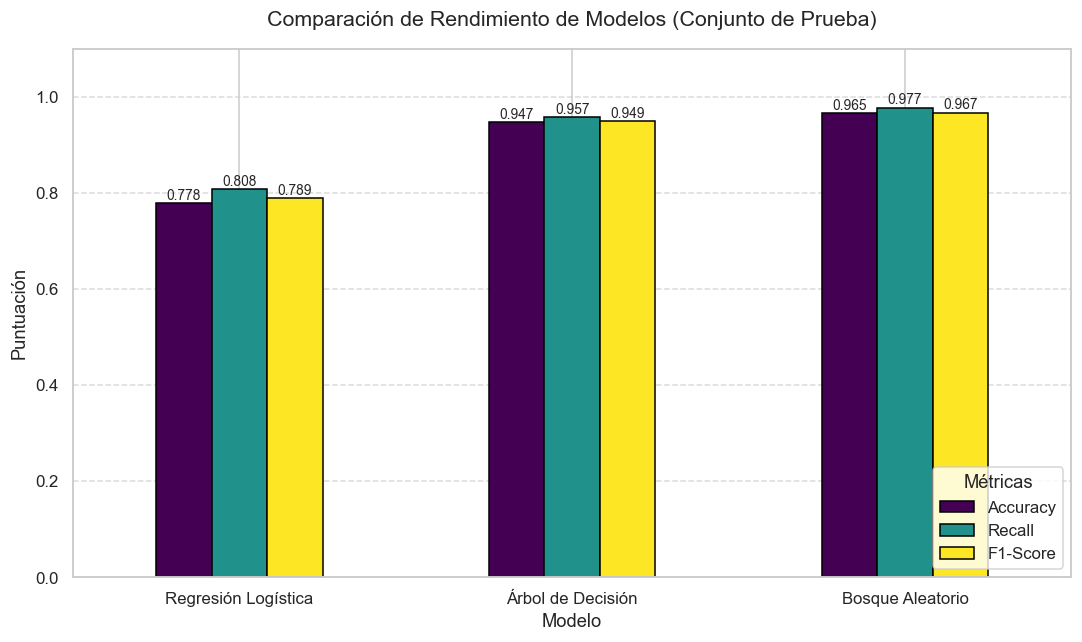

In [176]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

resultados = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Bosque Aleatorio'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr), 
        accuracy_score(y_test, y_test_pred_dt), 
        accuracy_score(y_test, y_test_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_lr), 
        recall_score(y_test, y_test_pred_dt), 
        recall_score(y_test, y_test_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_lr), 
        f1_score(y_test, y_test_pred_dt), 
        f1_score(y_test, y_test_pred_rf)
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados.set_index('Modelo', inplace=True)

display(df_resultados)

ax = df_resultados.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')

plt.title('Comparación de Rendimiento de Modelos (Conjunto de Prueba)', fontsize=14, pad=15)
plt.ylabel('Puntuación', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='lower right', title='Métricas')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

### 2.4.1. Matrices de Confusión
Visualización gráfica de las matrices de confusión para analizar los aciertos y errores de clasificación de cada modelo en el conjunto de prueba.

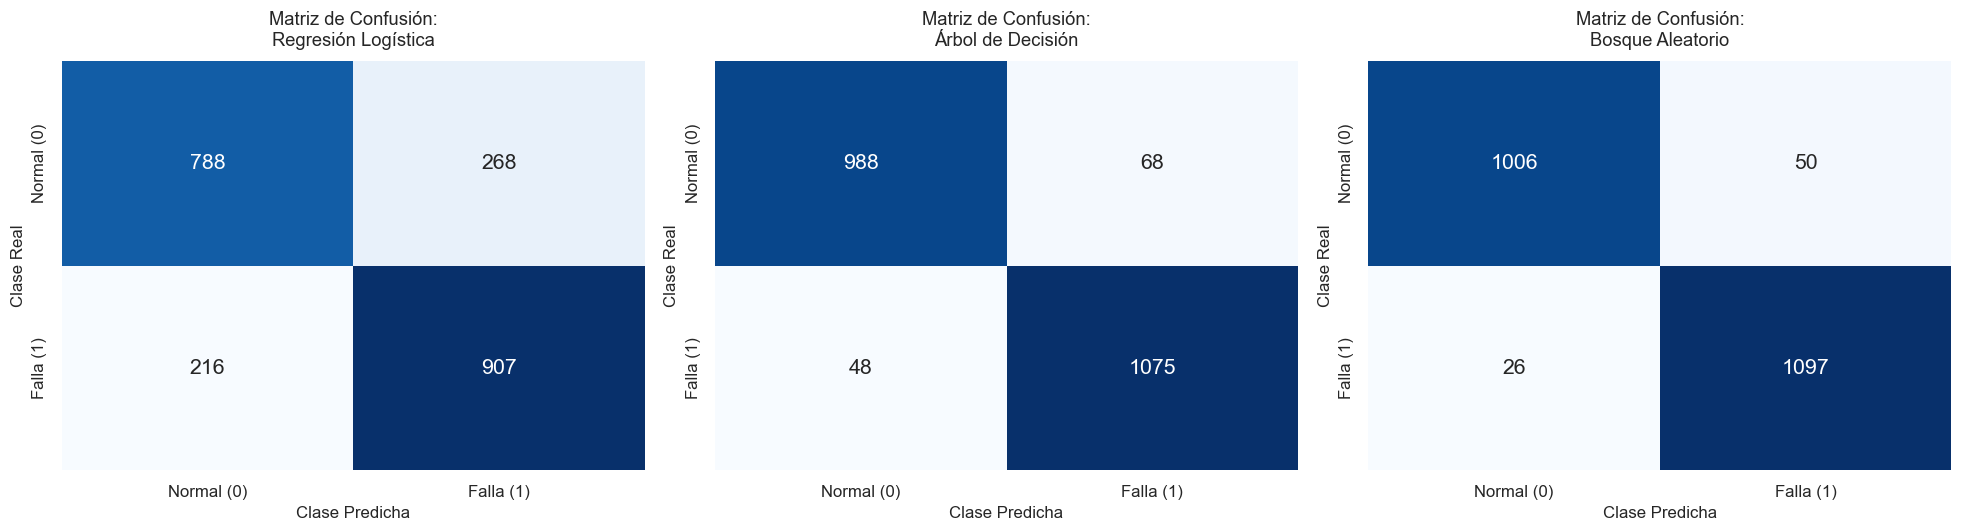

In [177]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_pred = [
    ("Regresión Logística", y_test_pred_lr),
    ("Árbol de Decisión", y_test_pred_dt),
    ("Bosque Aleatorio", y_test_pred_rf)
]

for ax, (nombre, pred) in zip(axes, modelos_pred):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Normal (0)', 'Falla (1)'], 
                yticklabels=['Normal (0)', 'Falla (1)'],
                annot_kws={'size': 14})
    
    ax.set_title(f'Matriz de Confusión:\n{nombre}', fontsize=12, pad=10)
    ax.set_ylabel('Clase Real', fontsize=11)
    ax.set_xlabel('Clase Predicha', fontsize=11)

plt.tight_layout()
plt.show()